In [1]:
import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')


In [2]:
%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import matplotlib as mpl

import regionmask
import geopandas as gpd
import pandas as pd
regionmask.__version__
#Yvans
import mw_protocol.plotting as plotting
import mw_protocol.saving as saving
import mw_protocol.glac1d_toolbox as tb
import pylaeoclim_leeds.util_hadcm3 as util

#Mine
import mymodules.myfunc as mf 


colores = {'0':'tab:blue', '1':'tab:orange', '2':'tab:green', '3':'tab:red', '4':'tab:purple', '5':'tab:brown', '6':'tab:pink',
         '7':'tab:olive', '8':'tab:cyan'}

In [3]:
# Dye and d18O information
from myconfig.DYES import DYE_TABLE
DYE_TO_REGION = dict(zip(DYE_TABLE["dye"], DYE_TABLE["region"]))

gdg = pd.read_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl")

gdg['Newnames'] = DYE_TABLE["region"]

lookup = {}
lookup_dis = {}

for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    lookup[sce] = mf.build_d18O_lookup(
        gdg,
        column=f"mean (-35.0) region d18O anomaly {sce}")

    lookup_dis[sce] = mf.build_d18O_lookup(
        gdg,
        column=f"Region Melt {sce} (Sv)")
    


new_keys = ['17.8k', '18.2k', '19.4k', '20.7k']
lookup = dict(zip(new_keys, lookup.values()))
lookup_dis = dict(zip(new_keys, lookup_dis.values())) #in mSv


#Regions
ds_dyeregion = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
dyen = list(ds_dyeregion.data_vars)

dye_colors = {'dye00':'tab:blue', 'dye01':'tab:orange', 'dye02':'tab:green', 'dye03':'tab:red', 'dye04':'tab:purple', 'dye05':'tab:brown', 'dye06':'tab:pink',
         'dye07':'tab:olive', 'dye08':'tab:cyan'}



In [4]:
from myconfig.PROXYSITES import PROXYSITES 
modes = ["xqeie", "xqeic"]  # zonal, cold


PROXYSITES = {
    k: v
    for k, v in PROXYSITES.items()
    if k != "Llarga Cave"
}


#PROXYSITES = [
#    (name, site)
#    for name, site in PROXYSITES.items()
#    if name != "Llarga Cave"
#]

PROXYSITES

{'MD95-2010': {'lat': 66.6833,
  'lon': -4.5667,
  'depth': 1226,
  'type': 'Marine Sediment Core',
  'domain': 'ocean'},
 'PS2644-5': {'lat': 67.8667,
  'lon': -21.7667,
  'depth': 777,
  'type': 'Marine Sediment Core',
  'domain': 'ocean'},
 'MD03-2664': {'lat': 57.4333,
  'lon': -48.6,
  'depth': 3440,
  'type': 'Marine Sediment Core',
  'domain': 'ocean'},
 'ODP980': {'lat': 55.4833,
  'lon': -14.7,
  'depth': 2179,
  'type': 'Marine Sediment Core',
  'domain': 'ocean'},
 'MD95-2042': {'lat': 37.8,
  'lon': -10.1667,
  'depth': 3146,
  'type': 'Marine Sediment Core',
  'domain': 'ocean'},
 'MD02-2552': {'lat': 26.95,
  'lon': -91.35,
  'depth': 2250,
  'type': 'Marine Sediment Core',
  'domain': 'ocean'},
 'La Vallina (NISA)': {'lat': 43.4167,
  'lon': -4.8,
  'depth': None,
  'type': 'Speleothem',
  'domain': 'land'},
 'Cave Without a Name': {'lat': 29.8667,
  'lon': -98.6333,
  'depth': None,
  'type': 'Speleothem',
  'domain': 'land'},
 'NGRIP': {'lat': 75.1,
  'lon': -42.3167,


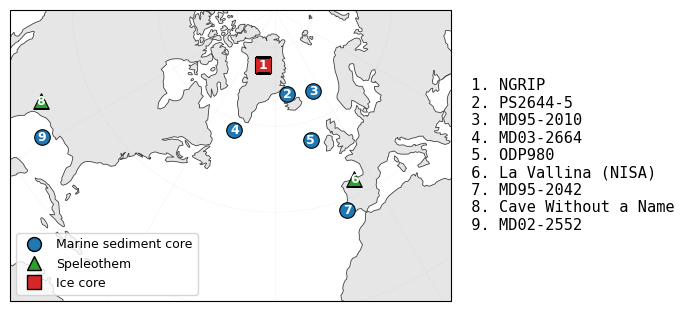

In [170]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# ==================================================
# Projection
# ==================================================

#projection = ccrs.NearsidePerspective(
#    central_longitude=-35,
#    central_latitude=45,
#    satellite_height=11000000,
#)

projection = ccrs.NorthPolarStereo(central_longitude=-30)

fig = plt.figure(figsize=(5.8, 5))
ax = plt.axes(projection=projection)

#ax.set_global()

# ==================================================
# Background
# ==================================================

ax.add_feature(
    cfeature.LAND,
    facecolor="0.9",
    edgecolor="none",
    zorder=0,
)

ax.coastlines(
    linewidth=0.6,
    color="0.25",
)

ax.gridlines(
    linestyle=":",
    linewidth=0.5,
    alpha=0.3,
    draw_labels=False,
)

# ==================================================
# Marker settings
# ==================================================

marker_style = {
    "Marine Sediment Core": {
        "marker": "o",
        "color": "tab:blue",
    },
    "Speleothem": {
        "marker": "^",
        "color": "tab:green",
    },
    "Ice Core": {
        "marker": "s",
        "color": "tab:red",
    },
}

# ==================================================
# Sort sites north -> south
# ==================================================

sites = sorted(
    PROXYSITES.items(),
    key=lambda x: x[1]["lat"],
    reverse=True,
)

# ==================================================
# Plot sites
# ==================================================

for number, (name, site) in enumerate(sites, start=1):

    style = marker_style[site["type"]]

    ax.scatter(
        site["lon"],
        site["lat"],
        s=125,
        marker=style["marker"],
        facecolor=style["color"],
        edgecolor="black",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=10,
    )

    ax.text(
        site["lon"],
        site["lat"],
        str(number),
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white",
        zorder=11,
    )

# ==================================================
# Numbered site list
# ==================================================

legend_text = "\n".join(
    f"{i:>2}. {name}"
    for i, (name, _) in enumerate(sites, start=1)
)

fig.text(
    0.80,
    0.50,
    legend_text,
    fontsize=11,
    va="center",
    family="monospace",
)

# ==================================================
# Symbol legend
# ==================================================

handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="",
        markersize=10,
        markerfacecolor="tab:blue",
        markeredgecolor="black",
        label="Marine sediment core",
    ),
    Line2D(
        [],
        [],
        marker="^",
        linestyle="",
        markersize=10,
        markerfacecolor="tab:green",
        markeredgecolor="black",
        label="Speleothem",
    ),
    Line2D(
        [],
        [],
        marker="s",
        linestyle="",
        markersize=10,
        markerfacecolor="tab:red",
        markeredgecolor="black",
        label="Ice core",
    ),
]

ax.legend(
    handles=handles,
    loc="lower left",
    frameon=True,
    fontsize=9,
)

ax.set_extent([-95, 7, 22, 90], crs=ccrs.PlateCarree())

# ==================================================
# Layout
# ==================================================

plt.subplots_adjust(
    left=0.02,
    right=0.78,
    top=0.98,
    bottom=0.02,
)

plt.savefig("my_output/chapter-four_latestfigures/Fig7_a_ProxySites_Map.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [5]:
# Dye and d18O information
from myconfig.DYES import DYE_TABLE
DYE_TO_REGION = dict(zip(DYE_TABLE["dye"], DYE_TABLE["region"]))

gdg = pd.read_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl")

gdg['Newnames'] = DYE_TABLE["region"]

lookup = {}
lookup_dis = {}

for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    lookup[sce] = mf.build_d18O_lookup(
        gdg,
        column=f"mean (-35.0) region d18O anomaly {sce}")

    lookup_dis[sce] = mf.build_d18O_lookup(
        gdg,
        column=f"Region Melt {sce} (Sv)")
    


new_keys = ['17.8k', '18.2k', '19.4k', '20.7k']
lookup = dict(zip(new_keys, lookup.values()))
lookup_dis = dict(zip(new_keys, lookup_dis.values())) #in mSv


#Regions
ds_dyeregion = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
dyen = list(ds_dyeregion.data_vars)



In [6]:
from mymodules.d18O_computation import build_d18O_results
from myconfig.EXPERIMENTS import EXPERIMENTS

from mymodules.dyefield_computation import run_pipeline


results = run_pipeline(
    experiments=EXPERIMENTS,
    outdir="myintermediates/dyestuff_modelpaper/",
    keep_in_memory=True, # put it in my jupyter Notebook memory
    save=True,
    overwrite=False, # If the data is already there - do not overwrite but just lazy load the existing files
    exclude=('xqeic','xqeie'), #simulations to be excluded here from the total experiments
    preflight=False, #You need to make this false if you don't need it, else it takes time!
)

dye_lat = results['cold']['xpujf'].latitude
dye_lon = results['cold']['xpujf'].longitude


===== COLD =====


cold: 100%|███████████████████████████████| 5/5 [00:01<00:00,  4.06experiment/s]



===== MERID =====


merid: 100%|██████████████████████████████| 4/4 [00:00<00:00,  5.59experiment/s]



===== ZONAL =====


zonal: 100%|██████████████████████████████| 4/4 [00:00<00:00,  8.46experiment/s]


✓ Pipeline finished.


In [41]:
dict_dye['zonal']['dye00']

<xarray.DataArray 'dye00' (lat: 144, lon: 288)>
array([[0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       [     nan,      nan,      nan, ...,      nan,      nan,      nan],
       ...,
       [0.001921, 0.001921, 0.00192 , ..., 0.001922, 0.001922, 0.001922],
       [0.001903, 0.001903, 0.001902, ..., 0.001905, 0.001904, 0.001904],
       [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ]],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float32 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8

In [7]:
#landmask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm
    lon_lsm, lat_lsm = ds_lsm.longitude.values, ds_lsm.latitude.values
    lon_lsm_b, lat_lsm_b = tb.create_coordinate_edges(lon_lsm), lat_lsm
#lsm = ds_lsm.lsm
#ds_lsm


[Land sea mask loader]
Elapsed: 0.17372822761535645


In [8]:
# Load Uptake Mask

import pickle

with open("myintermediates/dyestuff_modelpaper/land_uptakemasks.pkl", "rb") as f:
    uptake_masks = pickle.load(f)

uptake_masks = {
    "La Vallina (NISA)": uptake_masks.pop("NISA"),
    "Cave Without a Name": uptake_masks.pop("NoNameCave"),
    "NGRIP": uptake_masks.pop("NGRIP"),
}

In [9]:
# --- Compute grid cell area in m² ---
# 1° ~ 111 km, so 1.25° cell = 1.25 * 111 km ≈ 138.75 km
R = 6.371e6  # Earth radius in m
lat_rad = np.deg2rad(dye_lat)
# Area per cell (m²)
dlat = np.deg2rad(1.25)
dlon = np.deg2rad(1.25)
cell_area = (
    (R**2) * np.abs(np.sin(lat_rad + dlat/2) - np.sin(lat_rad - dlat/2)) * dlon
)
cell_area = xr.DataArray(cell_area, coords=[dye_lat], dims=["latitude"])

# Broadcast to 2D
area_2d = cell_area * xr.ones_like(results['cold']['xpujf']['dye00_mean'].isel(depth_1=0))


field = results[mode][experiment][f'dye0{d}_mean'].isel(depth_1=0)
field
uptake_mask


extract_land_proxy(field, uptake_mask, area_2d)

NameError: name 'mode' is not defined

In [ ]:
uptake_mask = uptake_mask.rename({
    "lat": "latitude",
    "lon": "longitude",
})

weights = uptake_mask * area_2d
weights = weights / weights.sum()
float(weights.sum())

In [ ]:
weights

In [ ]:
weights = uptake_mask * area_2d #/ 100.0

weights.sum(skipna=True).values

In [ ]:
weights.sum(dim=["latitude", "longitude"]).values

In [18]:
# If no new calculation just load from pickle!

#import pickle 

#with open("myintermediates/dyestuff_modelpaper/proxymag.pkl", "rb") as f: 
#    pickle.dump(proxymag, f, protocol=pickle.HIGHEST_PROTOCOL)

# Else Compute at Proxy sites

import numpy as np
import xarray as xr
from tqdm import tqdm



# ==================================================
# Settings
# ==================================================

scenarios = [
    "17.8k",
    "19.4k",
]

modes = [
    "zonal",
    "cold",
]

uptake_modes = {
    "zonal": "xqeie",
    "cold": "xqeic",
}


dyes = DYE_TABLE["dye"].tolist()


# --- Compute grid cell area in m² ---
# 1° ~ 111 km, so 1.25° cell = 1.25 * 111 km ≈ 138.75 km
R = 6.371e6  # Earth radius in m
lat_rad = np.deg2rad(dye_lat)
# Area per cell (m²)
dlat = np.deg2rad(1.25)
dlon = np.deg2rad(1.25)
cell_area = (
    (R**2) * np.abs(np.sin(lat_rad + dlat/2) - np.sin(lat_rad - dlat/2)) * dlon
)
cell_area = xr.DataArray(cell_area, coords=[dye_lat], dims=["latitude"])

# Broadcast to 2D
area_2d = cell_area * xr.ones_like(results['cold']['xpujf']['dye00_mean'].isel(depth_1=0))


# ==================================================
# Ocean proxy extraction
# ==================================================

def extract_ocean_proxy(field, lat, lon, size=2):
    """
    Extract mean field value around ocean proxy location.

    Parameters
    ----------
    field : xarray.DataArray
        latitude x longitude field
    lat, lon : float
        proxy location
    size : int
        number of grid cells around point

    """

    # account for longitude convention 0-360
    if lon < 0:
        lon = lon + 360


    subset = field.sel(
        latitude=slice(lat-size, lat+size),
        longitude=slice(lon-size, lon+size),
    )

    weights = np.cos(np.deg2rad(subset.latitude))
    subset = subset.weighted(weights)

    return float(subset.mean(skipna=True))


# ==================================================
# Land proxy extraction
# ==================================================

def extract_land_proxy(field, uptake, area):
    """
    Compute uptake-weighted land proxy value.

    Parameters
    ----------
    field : DataArray
        Quantity to average (e.g. dye field).

    uptake : DataArray
        Uptake percentage (0-100).

    area : DataArray
        Grid-cell area (same grid).
    """

    uptake = uptake.rename({
            "lat": "latitude",
            "lon": "longitude",
        })
    
    weights = uptake * area #/ 100.0

    weights = weights / weights.sum(skipna=True)

    return float(
        (field * weights).sum(skipna=True)
    )

# ==================================================
# Main calculation
# ==================================================

proxymag = {}


for scen in scenarios:

    proxymag[scen] = {}

    for mode in modes:

        proxymag[scen][mode] = {}

        # Log
        print(f"\nProcessing {mode} - {scen}")


        # --------------------------------------------------
        # Loop proxy sites
        # --------------------------------------------------

        for site, info in tqdm(
                PROXYSITES.items(),
                desc=f"{mode} {scen}",
                unit="site"
                ):

            proxymag[scen][mode][site] = {}


            contribution_sum = 0


            # --------------------------------------------------
            # Loop dyes
            # --------------------------------------------------

            for d in range(9):


                # ----------------------------------------------
                # get experiment name
                # ----------------------------------------------

                experiment = EXPERIMENTS[mode][scen]["exp"]

                
                # ----------------------------------------------
                # Get dye field
                # ----------------------------------------------


                field = results[mode][experiment][f'dye0{d}_mean'].isel(depth_1=0)


                # ----------------------------------------------
                # Extract proxy response
                # ----------------------------------------------

                

                if info["type"] == "Marine Sediment Core":
    
                        value = extract_ocean_proxy(
                            field,
                            info["lat"],
                            info["lon"],
                        )
    
    
                elif info["type"] in [
                        "Speleothem",
                        "Ice Core",
                    ]:
    
                        uptake_mask = uptake_masks[site][uptake_modes[mode]]
    
                        value = extract_land_proxy(
                            field,
                            uptake_mask,
                            area_2d
                        )
    
                else:
                        raise ValueError(
                            f"Unknown proxy type {info['type']}"
                        )


                # absolute contribution in d18O space
                #value = abs(value)


                proxymag[scen][mode][site][f'dye0{d}'] = value * lookup[scen][f'dye0{d}']


                contribution_sum += value * lookup[scen][f'dye0{d}']



            # --------------------------------------------------
            # Total contribution
            # --------------------------------------------------

            proxymag[scen][mode][site]["total"] = contribution_sum


Processing zonal - 17.8k


zonal 17.8k: 100%|██████████████████████████████| 9/9 [00:01<00:00,  6.80site/s]



Processing cold - 17.8k


cold 17.8k: 100%|███████████████████████████████| 9/9 [00:01<00:00,  6.96site/s]



Processing zonal - 19.4k


zonal 19.4k: 100%|██████████████████████████████| 9/9 [00:01<00:00,  5.23site/s]



Processing cold - 19.4k


cold 19.4k: 100%|███████████████████████████████| 9/9 [00:01<00:00,  5.24site/s]


In [19]:
# Save to Pickle
import pickle 

with open("myintermediates/dyestuff_modelpaper/proxymag.pkl", "wb") as f: 
    pickle.dump(proxymag, f, protocol=pickle.HIGHEST_PROTOCOL)




In [29]:
scen_mode = [
    ("17.8k", "cold"),
    ("17.8k", "zonal"),
    ("19.4k", "cold"),
    ("19.4k", "zonal"),
]

xmax = 0.4

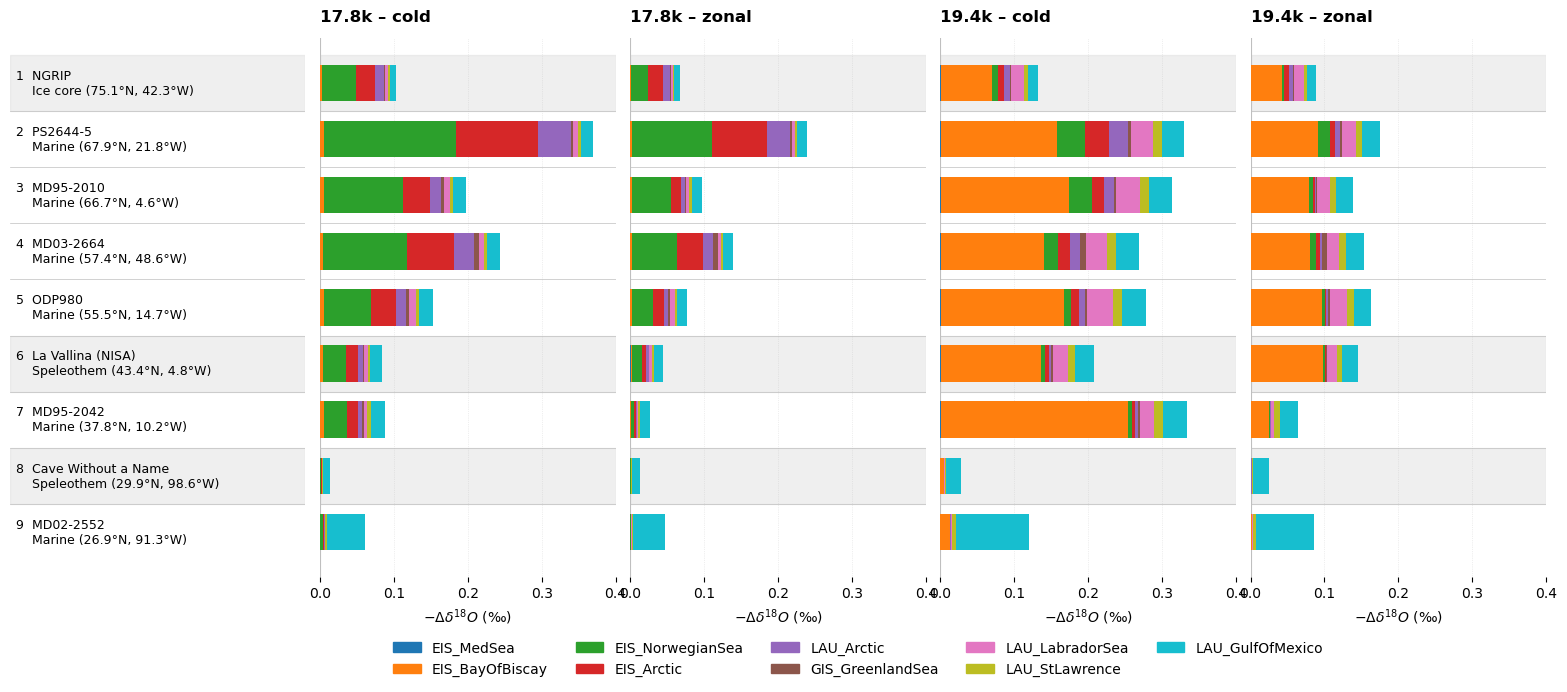

In [30]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================================
# Dye names
# ==========================================================

dye_labels = {
    row["dye"]: row["region"]
    for _,row in DYE_TABLE.iterrows()
}

dye_colors = {'dye00':'tab:blue', 'dye01':'tab:orange', 'dye02':'tab:green', 'dye03':'tab:red', 'dye04':'tab:purple', 'dye05':'tab:brown', 'dye06':'tab:pink',
         'dye07':'tab:olive', 'dye08':'tab:cyan'}


# ==========================================================
# Sort sites north -> south from PROXYSITES
# ==========================================================

sites = sorted(
    PROXYSITES.items(),
    key=lambda x: x[1]["lat"],
    reverse=True,
)

site_order = [s[0] for s in sites]

site_numbers = {
    site: i + 1
    for i, site in enumerate(site_order)
}


# ==========================================================
# Identify land sites
# ==========================================================

land_indices = [
    i for i, site in enumerate(site_order)
    if PROXYSITES[site]["domain"] == "land"
]


# ==========================================================
# Figure layout
# ==========================================================

fig = plt.figure(figsize=(16, 7))

gs = gridspec.GridSpec(
    nrows=1,
    ncols=5,
    width_ratios=[1, 1, 1, 1, 1],
    wspace=0.05
)

ax_label = fig.add_subplot(gs[0, 0])

axes = [
    fig.add_subplot(
        gs[0, i],
        sharey=ax_label
    )
    for i in range(1, 5)
]


# ==========================================================
# Common y-axis (north -> south)
# ==========================================================

for ax in [ax_label] + axes:
    ax.set_ylim(
        len(site_order)-0.2,
        -0.8
    )


# ==========================================================
# Label panel
# ==========================================================

ax_label.set_xlim(0, 1)
ax_label.axis("off")


# grey background behind labels
for i in land_indices:

    ax_label.axhspan(
        i - 0.5,
        i + 0.5,
        color="lightgrey",
        alpha=0.35,
        zorder=0
    )


# row separators behind labels
for y in range(1, len(site_order)):

    ax_label.axhline(
        y - 0.5,
        color="0.75",
        linewidth=0.5,
        zorder=1
    )


# vertical separator between labels and plots
ax_label.spines["right"].set_visible(True)
ax_label.spines["right"].set_color("0.75")
ax_label.spines["right"].set_linewidth(0.8)


# labels
for i, site in enumerate(site_order):

    info = PROXYSITES[site]

    lat = info["lat"]
    lon = info["lon"]

    lat_text = f"{abs(lat):.1f}°{'N' if lat >= 0 else 'S'}"
    lon_text = f"{abs(lon):.1f}°{'E' if lon >= 0 else 'W'}"

    type_short = {
        "Marine Sediment Core": "Marine",
        "Speleothem": "Speleothem",
        "Ice Core": "Ice core",
    }

    label = (
        f"{site_numbers[site]}  {site}\n"
        f"    {type_short.get(info['type'], info['type'])} "
        f"({lat_text}, {lon_text})"
    )

    ax_label.text(
        0.02,
        i,
        label,
        ha="left",
        va="center",
        fontsize=9
    )


# ==========================================================
# Bar plots
# ==========================================================

for ax, (scenario, mode) in zip(axes, scen_mode):


    # grey background for land sites
    for i in land_indices:

        ax.axhspan(
            i - 0.5,
            i + 0.5,
            color="lightgrey",
            alpha=0.35,
            zorder=0
        )


    # stacked bars
    for i, site in enumerate(site_order):

        left = 0

        for dye in dyes:

            value = abs(
                proxymag[scenario][mode][site][dye]
            )

            ax.barh(
                i,
                value,
                left=left,
                height=0.65,
                color=dye_colors[dye],
                edgecolor="none",
                zorder=3
            )

            left += value


    # limits
    ax.set_xlim(
        0,
        xmax
    )


    # remove panel boxes
    for spine in ax.spines.values():
        spine.set_visible(False)


    # row separators
    for y in range(1, len(site_order)):

        ax.axhline(
            y - 0.5,
            color="0.75",
            linewidth=0.5,
            zorder=2
        )


    # column separators
    ax.axvline(
        0,
        color="0.75",
        linewidth=0.8,
        zorder=2
    )


    # grid
    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.5,
        alpha=0.4,
        zorder=1
    )

    ax.set_axisbelow(True)


    # left aligned titles
    ax.set_title(
        f"{scenario} – {mode}",
        fontsize=12,
        weight="bold",
        loc="left",
        pad=12
    )


    ax.set_xlabel(
        r"$-\Delta\delta^{18}O$ (‰)",
        fontsize=10
    )


    ax.tick_params(
        axis="y",
        left=False,
        labelleft=False
    )


# ==========================================================
# Legend
# ==========================================================

handles=[
    mpl.patches.Patch(
        color=dye_colors[dye],
        label=dye_labels[dye]
    )
    for dye in dyes
]

fig.legend(
    handles=handles,
    #labels=dye_labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.55, -0.03)
)


# ==========================================================
# Title and spacing
# ==========================================================

#fig.suptitle(
#    "Contribution of meltwater source regions to proxy-site δ$^{18}$O anomalies",
#    fontsize=14,
#    weight="bold",
#    x=0.5
#)


plt.subplots_adjust(
    left=0.02,
    right=0.98,
    bottom=0.13,
    top=0.90
)

plt.savefig("my_output/chapter-four_latestfigures/Fig7_b_ProxySites_Bars.pdf", dpi=300, bbox_inches="tight")

#plt.show()

NameError: name 'xmax' is not defined

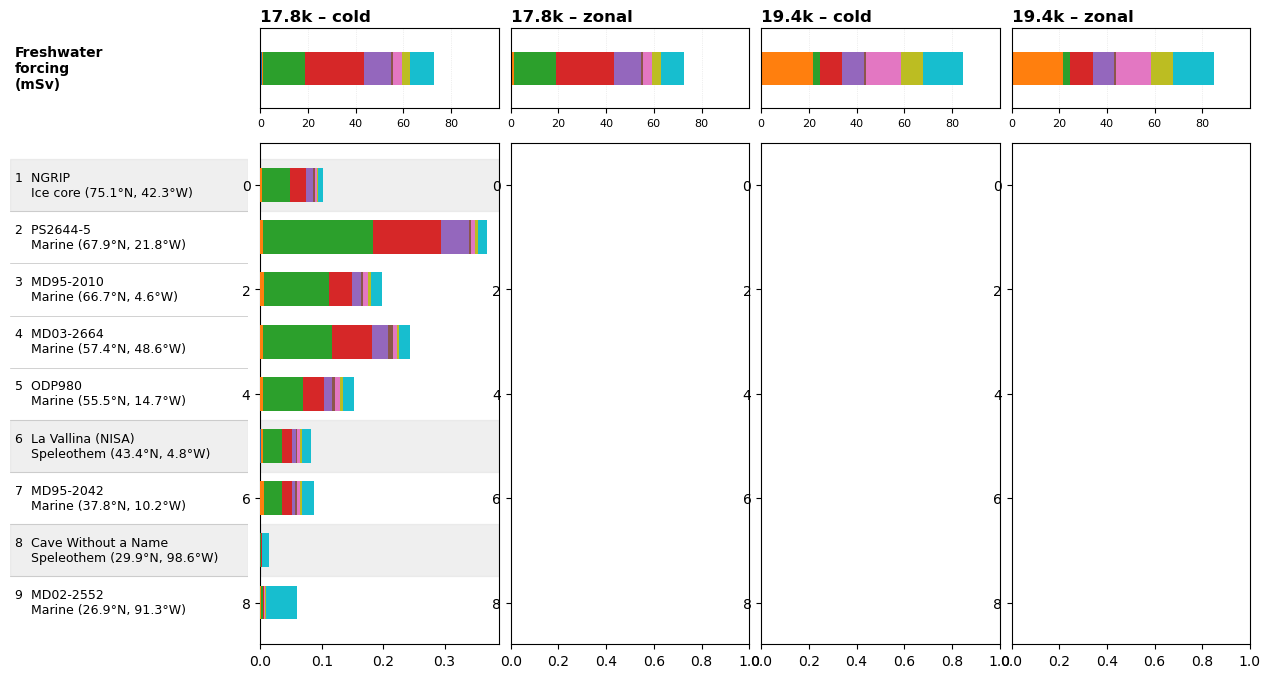

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================================
# Dye names
# ==========================================================

dye_labels = {
    row["dye"]: row["region"]
    for _,row in DYE_TABLE.iterrows()
}

dye_colors = {'dye00':'tab:blue', 'dye01':'tab:orange', 'dye02':'tab:green', 'dye03':'tab:red', 'dye04':'tab:purple', 'dye05':'tab:brown', 'dye06':'tab:pink',
         'dye07':'tab:olive', 'dye08':'tab:cyan'}

scale_Sv_to_mSv = 1000
xmax_discharge = 100

region_names = list(lookup_dis["17.8k"].keys())




# ==========================================================
# Sort sites north -> south from PROXYSITES
# ==========================================================

sites = sorted(
    PROXYSITES.items(),
    key=lambda x: x[1]["lat"],
    reverse=True,
)

site_order = [s[0] for s in sites]

site_numbers = {
    site: i + 1
    for i, site in enumerate(site_order)
}


# ==========================================================
# Identify land sites
# ==========================================================

land_indices = [
    i for i, site in enumerate(site_order)
    if PROXYSITES[site]["domain"] == "land"
]


# ==========================================================
# Figure layout (discharge row + proxy contribution row)
# ==========================================================

fig = plt.figure(figsize=(16, 8))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=5,
    height_ratios=[0.16, 1],
    width_ratios=[1, 1, 1, 1, 1],
    hspace=0.12,
    wspace=0.05
)


# empty label space above site names
ax_dis_label = fig.add_subplot(gs[0,0])
ax_dis_label.axis("off")


# discharge axes
bar_axes = [
    fig.add_subplot(gs[0,i])
    for i in range(1,5)
]


# site labels
ax_label = fig.add_subplot(gs[1,0])


# proxy contribution axes
axes = [
    fig.add_subplot(
        gs[1,i],
        sharey=ax_label
    )
    for i in range(1,5)
]


# ==========================================================
# Common y-axis (north -> south)
# ==========================================================

for ax in [ax_label] + axes:
    ax.set_ylim(
        len(site_order)-0.2,
        -0.8
    )


# ==========================================================
# Label panel
# ==========================================================

ax_label.set_xlim(0, 1)
ax_label.axis("off")


# grey background behind labels
for i in land_indices:

    ax_label.axhspan(
        i - 0.5,
        i + 0.5,
        color="lightgrey",
        alpha=0.35,
        zorder=0
    )


# row separators behind labels
for y in range(1, len(site_order)):

    ax_label.axhline(
        y - 0.5,
        color="0.75",
        linewidth=0.5,
        zorder=1
    )


# vertical separator between labels and plots
ax_label.spines["right"].set_visible(True)
ax_label.spines["right"].set_color("0.75")
ax_label.spines["right"].set_linewidth(0.8)


# labels
for i, site in enumerate(site_order):

    info = PROXYSITES[site]

    lat = info["lat"]
    lon = info["lon"]

    lat_text = f"{abs(lat):.1f}°{'N' if lat >= 0 else 'S'}"
    lon_text = f"{abs(lon):.1f}°{'E' if lon >= 0 else 'W'}"

    type_short = {
        "Marine Sediment Core": "Marine",
        "Speleothem": "Speleothem",
        "Ice Core": "Ice core",
    }

    label = (
        f"{site_numbers[site]}  {site}\n"
        f"    {type_short.get(info['type'], info['type'])} "
        f"({lat_text}, {lon_text})"
    )

    ax_label.text(
        0.02,
        i,
        label,
        ha="left",
        va="center",
        fontsize=9
    )



# ==========================================================
# Freshwater discharge bars
# ==========================================================

for ax, (scenario, mode) in zip(bar_axes, scen_mode):

    left = 0

    for dye in dyes:

        #region = dye_labels[dye]

        value = (
            lookup_dis[scenario]
            .get(dye, 0.0)
            * scale_Sv_to_mSv
        )


        ax.barh(
            0,
            value,
            left=left,
            height=0.65,
            color=dye_colors[dye],
            edgecolor="none",
        )

        left += value


    ax.set_xlim(
        0,
        xmax_discharge
    )

    ax.set_ylim(
        -0.8,
        0.8
    )


    ax.set_title(
        f"{scenario} – {mode}",
        fontsize=12,
        weight="bold",
        loc="left",
        pad=5
    )


    ax.set_yticks([])


    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.5,
        alpha=0.4
    )


    ax.set_axisbelow(True)


    for spine in ax.spines.values():
        spine.set_visible(True)

    ax.set_xticks([0, 20, 40,60,80])
    ax.set_xticklabels(
        ["0", "20", "40","60", "80"],
        fontsize=8
    )


    #ax.tick_params(
    #    bottom=False,
    #    labelbottom=False,
    #    left=False
    #)


# label for discharge row
ax_dis_label.text(
    0.02,
    0.5,
    "Freshwater\nforcing\n(mSv)",
    fontsize=10,
    weight="bold",
    ha="left",
    va="center",
)


# ==========================================================
# Bar plots
# ==========================================================

for ax, (scenario, mode) in zip(axes, scen_mode):


    # grey background for land sites
    for i in land_indices:

        ax.axhspan(
            i - 0.5,
            i + 0.5,
            color="lightgrey",
            alpha=0.35,
            zorder=0
        )


    # stacked bars
    for i, site in enumerate(site_order):

        left = 0

        for dye in dyes:

            value = abs(
                proxymag[scenario][mode][site][dye]
            )

            ax.barh(
                i,
                value,
                left=left,
                height=0.65,
                color=dye_colors[dye],
                edgecolor="none",
                zorder=3
            )

            left += value


    # limits
    ax.set_xlim(
        0,
        xmax
    )


    # remove panel boxes
    for spine in ax.spines.values():
        spine.set_visible(False)


    # row separators
    for y in range(1, len(site_order)):

        ax.axhline(
            y - 0.5,
            color="0.75",
            linewidth=0.5,
            zorder=2
        )


    # column separators
    ax.axvline(
        0,
        color="0.75",
        linewidth=0.8,
        zorder=2
    )


    # grid
    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.5,
        alpha=0.4,
        zorder=1
    )

    ax.set_axisbelow(True)


    # left aligned titles
    #ax.set_title(
    #    f"{scenario} – {mode}",
    #    fontsize=12,
    #    weight="bold",
    #    loc="left",
    #    pad=12
    #)


    ax.set_xlabel(
        r"$-\Delta\delta^{18}O$ (‰)",
        fontsize=10
    )


    ax.tick_params(
        axis="y",
        left=False,
        labelleft=False
    )


# ==========================================================
# Legend
# ==========================================================

handles=[
    mpl.patches.Patch(
        color=dye_colors[dye],
        label=dye_labels[dye]
    )
    for dye in dyes
]

fig.legend(
    handles=handles,
    #labels=dye_labels,
    loc="lower center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.55, -0.03)
)


# ==========================================================
# Title and spacing
# ==========================================================

#fig.suptitle(
#    "Contribution of meltwater source regions to proxy-site δ$^{18}$O anomalies",
#    fontsize=14,
#    weight="bold",
#    x=0.5
#)








plt.subplots_adjust(
    left=0.02,
    right=0.98,
    bottom=0.12,
    top=0.95
)

plt.savefig("my_output/chapter-four_latestfigures/Fig7_b_ProxySites_Bars.pdf", dpi=300, bbox_inches="tight")



plt.show()

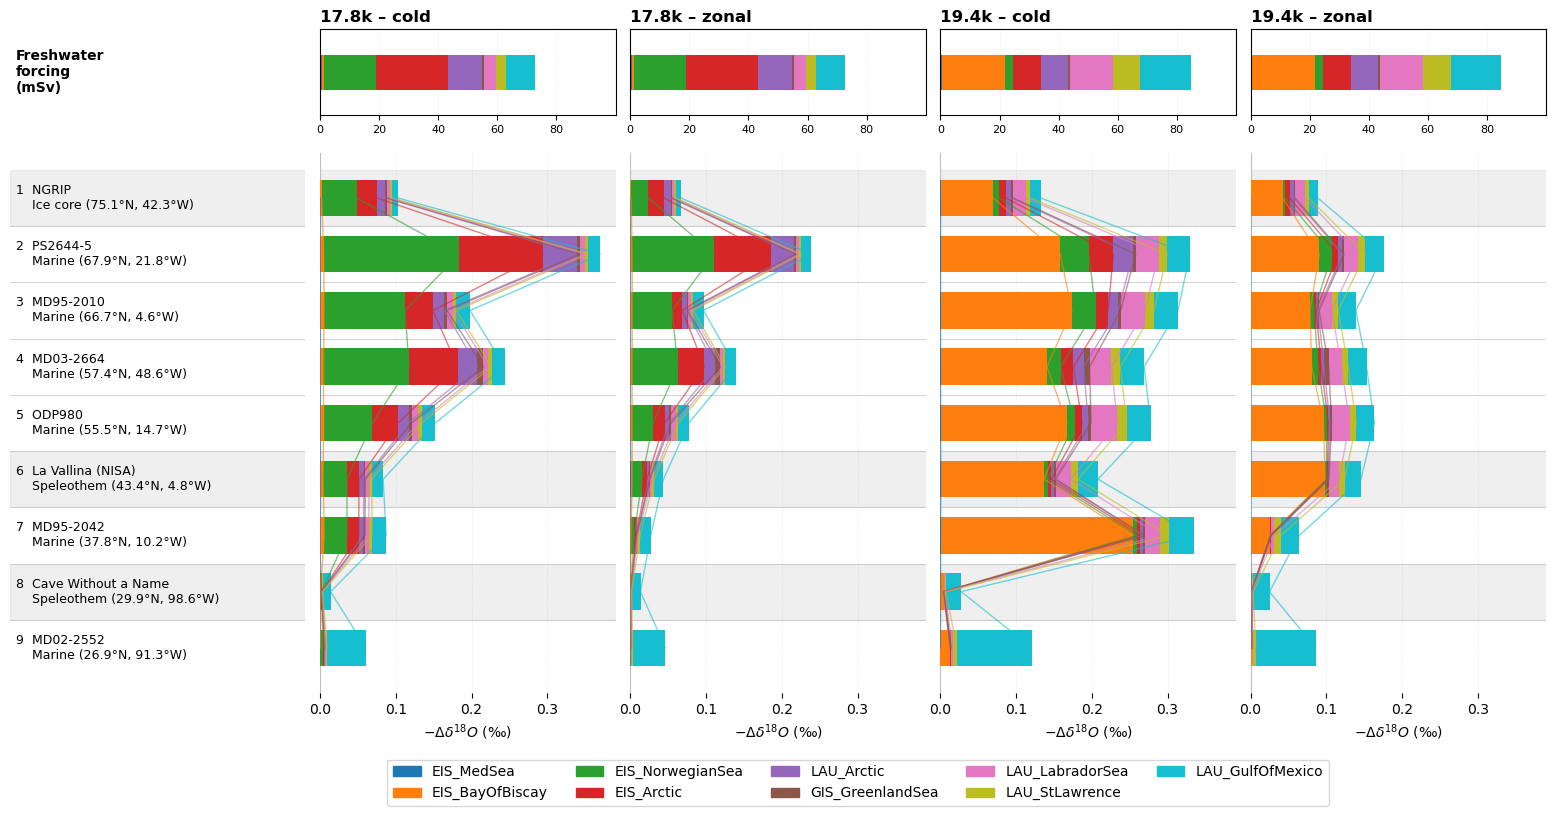

In [32]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================================
# Dye names
# ==========================================================

dye_labels = {
    row["dye"]: row["region"]
    for _,row in DYE_TABLE.iterrows()
}

dye_colors = {'dye00':'tab:blue', 'dye01':'tab:orange', 'dye02':'tab:green', 'dye03':'tab:red', 'dye04':'tab:purple', 'dye05':'tab:brown', 'dye06':'tab:pink',
         'dye07':'tab:olive', 'dye08':'tab:cyan'}

scale_Sv_to_mSv = 1000
xmax_discharge = 100

region_names = list(lookup_dis["17.8k"].keys())

xmax = 0.39



# ==========================================================
# Sort sites north -> south from PROXYSITES
# ==========================================================

sites = sorted(
    PROXYSITES.items(),
    key=lambda x: x[1]["lat"],
    reverse=True,
)

site_order = [s[0] for s in sites]

site_numbers = {
    site: i + 1
    for i, site in enumerate(site_order)
}


# ==========================================================
# Identify land sites
# ==========================================================

land_indices = [
    i for i, site in enumerate(site_order)
    if PROXYSITES[site]["domain"] == "land"
]


# ==========================================================
# Figure layout (discharge row + proxy contribution row)
# ==========================================================

fig = plt.figure(figsize=(16, 8))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=5,
    height_ratios=[0.16, 1],
    width_ratios=[1, 1, 1, 1, 1],
    hspace=0.12,
    wspace=0.05
)


# empty label space above site names
ax_dis_label = fig.add_subplot(gs[0,0])
ax_dis_label.axis("off")


# discharge axes
bar_axes = [
    fig.add_subplot(gs[0,i])
    for i in range(1,5)
]


# site labels
ax_label = fig.add_subplot(gs[1,0])


# proxy contribution axes
axes = [
    fig.add_subplot(
        gs[1,i],
        sharey=ax_label
    )
    for i in range(1,5)
]


# ==========================================================
# Common y-axis (north -> south)
# ==========================================================

for ax in [ax_label] + axes:
    ax.set_ylim(
        len(site_order)-0.2,
        -0.8
    )


# ==========================================================
# Label panel
# ==========================================================

ax_label.set_xlim(0, 1)
ax_label.axis("off")


# grey background behind labels
for i in land_indices:

    ax_label.axhspan(
        i - 0.5,
        i + 0.5,
        color="lightgrey",
        alpha=0.35,
        zorder=0
    )


# row separators behind labels
for y in range(1, len(site_order)):

    ax_label.axhline(
        y - 0.5,
        color="0.75",
        linewidth=0.5,
        zorder=1
    )


# vertical separator between labels and plots
ax_label.spines["right"].set_visible(True)
ax_label.spines["right"].set_color("0.75")
ax_label.spines["right"].set_linewidth(0.8)


# labels
for i, site in enumerate(site_order):

    info = PROXYSITES[site]

    lat = info["lat"]
    lon = info["lon"]

    lat_text = f"{abs(lat):.1f}°{'N' if lat >= 0 else 'S'}"
    lon_text = f"{abs(lon):.1f}°{'E' if lon >= 0 else 'W'}"

    type_short = {
        "Marine Sediment Core": "Marine",
        "Speleothem": "Speleothem",
        "Ice Core": "Ice core",
    }

    label = (
        f"{site_numbers[site]}  {site}\n"
        f"    {type_short.get(info['type'], info['type'])} "
        f"({lat_text}, {lon_text})"
    )

    ax_label.text(
        0.02,
        i,
        label,
        ha="left",
        va="center",
        fontsize=9
    )



# ==========================================================
# Freshwater discharge bars
# ==========================================================

for ax, (scenario, mode) in zip(bar_axes, scen_mode):

    left = 0

    for dye in dyes:

        #region = dye_labels[dye]

        value = (
            lookup_dis[scenario]
            .get(dye, 0.0)
            * scale_Sv_to_mSv
        )


        ax.barh(
            0,
            value,
            left=left,
            height=0.65,
            color=dye_colors[dye],
            edgecolor="none",
        )

        left += value


    ax.set_xlim(
        0,
        xmax_discharge
    )

    ax.set_ylim(
        -0.8,
        0.8
    )


    ax.set_title(
        f"{scenario} – {mode}",
        fontsize=12,
        weight="bold",
        loc="left",
        pad=5
    )


    ax.set_yticks([])


    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.5,
        alpha=0.4
    )


    ax.set_axisbelow(True)


    for spine in ax.spines.values():
        spine.set_visible(True)

    ax.set_xticks([0, 20, 40,60,80])
    ax.set_xticklabels(
        ["0", "20", "40","60", "80"],
        fontsize=8
    )


    #ax.tick_params(
    #    bottom=False,
    #    labelbottom=False,
    #    left=False
    #)


# label for discharge row
ax_dis_label.text(
    0.02,
    0.5,
    "Freshwater\nforcing\n(mSv)",
    fontsize=10,
    weight="bold",
    ha="left",
    va="center",
)


# ==========================================================
# Bar plots
# ==========================================================

for ax, (scenario, mode) in zip(axes, scen_mode):


    # grey background for land sites
    for i in land_indices:

        ax.axhspan(
            i - 0.5,
            i + 0.5,
            color="lightgrey",
            alpha=0.35,
            zorder=0
        )


    # store cumulative dye boundaries
    boundaries = {
        dye: []
        for dye in dyes
    }


    for i, site in enumerate(site_order):
    
        left = 0
    
        for dye in dyes:
    
            value = abs(
                proxymag[scenario][mode][site][dye]
            )
    
            # store right edge of this dye
            boundaries[dye].append(left + value)
    
            ax.barh(
                i,
                value,
                left=left,
                height=0.65,
                color=dye_colors[dye],
                edgecolor="none",
                zorder=3
            )
    
            left += value
    
    
    # connect dye contributions between sites
    for dye in dyes:
    
        ax.plot(
            boundaries[dye],
            range(len(site_order)),
            color=dye_colors[dye],
            linewidth=1,
            alpha=0.6,
            zorder=4
        )


    # limits
    ax.set_xlim(
        0,
        xmax
    )


    # remove panel boxes
    for spine in ax.spines.values():
        spine.set_visible(False)


    # row separators
    for y in range(1, len(site_order)):

        ax.axhline(
            y - 0.5,
            color="0.75",
            linewidth=0.5,
            zorder=2
        )


    # column separators
    ax.axvline(
        0,
        color="0.75",
        linewidth=0.8,
        zorder=2
    )


    # grid
    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.5,
        alpha=0.4,
        zorder=1
    )

    ax.set_axisbelow(True)


    # left aligned titles
    #ax.set_title(
    #    f"{scenario} – {mode}",
    #    fontsize=12,
    #    weight="bold",
    #    loc="left",
    #    pad=12
    #)


    ax.set_xlabel(
        r"$-\Delta\delta^{18}O$ (‰)",
        fontsize=10
    )


    ax.tick_params(
        axis="y",
        left=False,
        labelleft=False
    )


# ==========================================================
# Legend
# ==========================================================

handles=[
    mpl.patches.Patch(
        color=dye_colors[dye],
        label=dye_labels[dye]
    )
    for dye in dyes
]

fig.legend(
    handles=handles,
    #labels=dye_labels,
    loc="lower center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.55, -0.03)
)


# ==========================================================
# Title and spacing
# ==========================================================

#fig.suptitle(
#    "Contribution of meltwater source regions to proxy-site δ$^{18}$O anomalies",
#    fontsize=14,
#    weight="bold",
#    x=0.5
#)








plt.subplots_adjust(
    left=0.02,
    right=0.98,
    bottom=0.12,
    top=0.95
)

#plt.savefig("my_output/chapter-four_latestfigures/Fig7_b_ProxySites_Bars_var.pdf", dpi=300, bbox_inches="tight")



plt.show()

In [197]:
for scenario, mode in scen_mode:

    rows = []

    for site in site_order:

        row = {
            "site_number": site_numbers[site],
            "site": site,
            "type": PROXYSITES[site]["type"],
            "lat": PROXYSITES[site]["lat"],
            "lon": PROXYSITES[site]["lon"],
        }

        for dye in dyes:
            row[dye] = abs(
                proxymag[scenario][mode][site][dye]
            )

        row["total"] = sum(row[dye] for dye in dyes)

        rows.append(row)

    df_export = pd.DataFrame(rows)

    df_export.to_csv(
        f"my_output/{scenario}_{mode}_proxy_d18O_contributions.csv",
        index=False
    )

In [ ]:
### Predicted for the other two scenarios. 

In [33]:
# Load Mean values for prediction data sets.
# Test of the old vs new way of computing the mean values



# Load Dyes

ds_dye_zonal = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_zonal.nc')
ds_dye_cold = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_cold.nc')
ds_dye_merid = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_merid.nc')


dict_dye = {'zonal' : ds_dye_zonal,
     'cold' : ds_dye_cold,
     'merid' : ds_dye_merid
    }

gdf_list = ['17.8ka','18.2 ka','19.4 ka','20.7 ka']

for mode, ds_dye in dict_dye.items():

    for j in range(4):
        for i in range(9):
            ds_dye[f'{gdf_list[j]} dye0{i} d18O'] = ds_dye[f'dye0{i}']*gdg[f'mean (-35.0) region d18O anomaly {gdf_list[j]}'][i]
        
        ds_dye[f'{gdf_list[j]} total d18O'] = ds_dye[f'{gdf_list[j]} dye00 d18O'] + ds_dye[f'{gdf_list[j]} dye01 d18O'] + ds_dye[f'{gdf_list[j]} dye02 d18O'] + ds_dye[f'{gdf_list[j]} dye03 d18O'] + ds_dye[f'{gdf_list[j]} dye04 d18O'] + ds_dye[f'{gdf_list[j]} dye05 d18O'] + ds_dye[f'{gdf_list[j]} dye06 d18O'] + ds_dye[f'{gdf_list[j]} dye07 d18O'] + ds_dye[f'{gdf_list[j]} dye08 d18O']


d18O_results_predict = {}

scenarios_old = ["17.8ka", "18.2 ka", "19.4 ka", "20.7 ka"]
scenarios_new = ["17.8k", "18.2k", "19.4k", "20.7k"]


for mode in dict_dye:

    d18O_results_predict[mode] = {}

    for j,scen in enumerate(scenarios_old):

        old_key = f"{scen} total d18O"

        if old_key not in dict_dye[mode]:
            continue

        new_key = f"{scenarios_new[j]}_d18O_mean"

        d18O_results_predict[mode][new_key] = dict_dye[mode][old_key]

In [50]:
# If no new calculation just load from pickle!

#import pickle 

#with open("myintermediates/dyestuff_modelpaper/proxymag.pkl", "rb") as f: 
#    pickle.dump(proxymag, f, protocol=pickle.HIGHEST_PROTOCOL)

# Else Compute at Proxy sites

import numpy as np
import xarray as xr
from tqdm import tqdm

from myconfig.EXPERIMENTS_prediction import EXPERIMENTS_prediction


# ==================================================
# Settings
# ==================================================

scenarios = [
    "18.2k",
    "20.7k",
]

modes = [
    "zonal",
    "cold",
]

uptake_modes = {
    "zonal": "xqeie",
    "cold": "xqeic",
}


dyes = DYE_TABLE["dye"].tolist()


# --- Compute grid cell area in m² ---
# 1° ~ 111 km, so 1.25° cell = 1.25 * 111 km ≈ 138.75 km
R = 6.371e6  # Earth radius in m
lat_rad = np.deg2rad(dye_lat)
# Area per cell (m²)
dlat = np.deg2rad(1.25)
dlon = np.deg2rad(1.25)
cell_area = (
    (R**2) * np.abs(np.sin(lat_rad + dlat/2) - np.sin(lat_rad - dlat/2)) * dlon
)
cell_area = xr.DataArray(cell_area, coords=[dye_lat], dims=["latitude"])

# Broadcast to 2D
area_2d = cell_area * xr.ones_like(results['cold']['xpujf']['dye00_mean'].isel(depth_1=0))


# ==================================================
# Ocean proxy extraction
# ==================================================

def extract_ocean_proxy(field, lat, lon, size=2):
    """
    Extract mean field value around ocean proxy location.

    Parameters
    ----------
    field : xarray.DataArray
        latitude x longitude field
    lat, lon : float
        proxy location
    size : int
        number of grid cells around point

    """

    # account for longitude convention 0-360
    if lon < 0:
        lon = lon + 360


    # Determine coordinate names
    lat_name = "latitude" if "latitude" in field.coords else "lat"
    lon_name = "longitude" if "longitude" in field.coords else "lon"

    subset = field.sel(
        {
        lat_name : slice(lat-size, lat+size),
        lon_name : slice(lon-size, lon+size),
        }
    )

    weights = np.cos(np.deg2rad(subset[lat_name]))
    subset = subset.weighted(weights)

    return float(subset.mean(skipna=True))


# ==================================================
# Land proxy extraction
# ==================================================

def extract_land_proxy(field, uptake, area):
    """
    Compute uptake-weighted land proxy value.

    Parameters
    ----------
    field : DataArray
        Quantity to average (e.g. dye field).

    uptake : DataArray
        Uptake percentage (0-100).

    area : DataArray
        Grid-cell area (same grid).
    """

    # Determine coordinate names
    lat_name = "latitude" if "latitude" in field.coords else "lat"
    lon_name = "longitude" if "longitude" in field.coords else "lon"
    

    uptake = uptake.rename({
            "lat": lat_name,
            "lon": lon_name,
        })
    
    weights = uptake * area #/ 100.0

    weights = weights / weights.sum(skipna=True)

    return float(
        (field * weights).sum(skipna=True)
    )

# ==================================================
# Main calculation
# ==================================================

proxymag = {}


for scen in scenarios:

    proxymag[scen] = {}

    for mode in modes:

        proxymag[scen][mode] = {}

        # Log
        print(f"\nProcessing {mode} - {scen}")


        # --------------------------------------------------
        # Loop proxy sites
        # --------------------------------------------------

        for site, info in tqdm(
                PROXYSITES.items(),
                desc=f"{mode} {scen}",
                unit="site"
                ):

            proxymag[scen][mode][site] = {}


            contribution_sum = 0


            # --------------------------------------------------
            # Loop dyes
            # --------------------------------------------------

            for d in range(9):


                # ----------------------------------------------
                # get experiment name
                # ----------------------------------------------
                from myconfig.EXPERIMENTS_prediction import EXPERIMENTS_prediction
                experiment = EXPERIMENTS_prediction[mode][scen]["exp"]

                
                # ----------------------------------------------
                # Get dye field (here: predicted)
                # ----------------------------------------------


                field = dict_dye[mode][f'dye0{d}']#.isel(depth_1=0)


                # ----------------------------------------------
                # Extract proxy response
                # ----------------------------------------------

                

                if info["type"] == "Marine Sediment Core":
    
                        value = extract_ocean_proxy(
                            field,
                            info["lat"],
                            info["lon"],
                        )
    
    
                elif info["type"] in [
                        "Speleothem",
                        "Ice Core",
                    ]:
    
                        uptake_mask = uptake_masks[site][uptake_modes[mode]]
    
                        value = extract_land_proxy(
                            field,
                            uptake_mask,
                            area_2d
                        )
    
                else:
                        raise ValueError(
                            f"Unknown proxy type {info['type']}"
                        )


                # absolute contribution in d18O space
                #value = abs(value)


                proxymag[scen][mode][site][f'dye0{d}'] = value * lookup[scen][f'dye0{d}']


                contribution_sum += value * lookup[scen][f'dye0{d}']



            # --------------------------------------------------
            # Total contribution
            # --------------------------------------------------

            proxymag[scen][mode][site]["total"] = contribution_sum


Processing zonal - 18.2k


zonal 18.2k:  33%|██████████                    | 3/9 [00:00<00:00, 26.08site/s]/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lat' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lon' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
zonal 18.2k:  33%|██████████                    | 3/9 [00:18<00:00, 26.08site/s]/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lat' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lon' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after


Processing cold - 18.2k


cold 18.2k:  44%|█████████████▊                 | 4/9 [00:00<00:00, 35.86site/s]/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lat' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lon' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
cold 18.2k:  44%|█████████████▊                 | 4/9 [00:16<00:00, 35.86site/s]/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lat' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lon' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after


Processing zonal - 20.7k


zonal 20.7k:  44%|█████████████▎                | 4/9 [00:00<00:00, 35.56site/s]/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lat' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lon' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
zonal 20.7k:  44%|█████████████▎                | 4/9 [00:19<00:00, 35.56site/s]/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lat' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lon' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after


Processing cold - 20.7k


cold 20.7k:  44%|█████████████▊                 | 4/9 [00:00<00:00, 34.65site/s]/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lat' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lon' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
cold 20.7k:  44%|█████████████▊                 | 4/9 [00:13<00:00, 34.65site/s]/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lat' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  uptake = uptake.rename({
/tmp/ipykernel_23847/2672280044.py:122: UserWarning: rename 'lon' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after

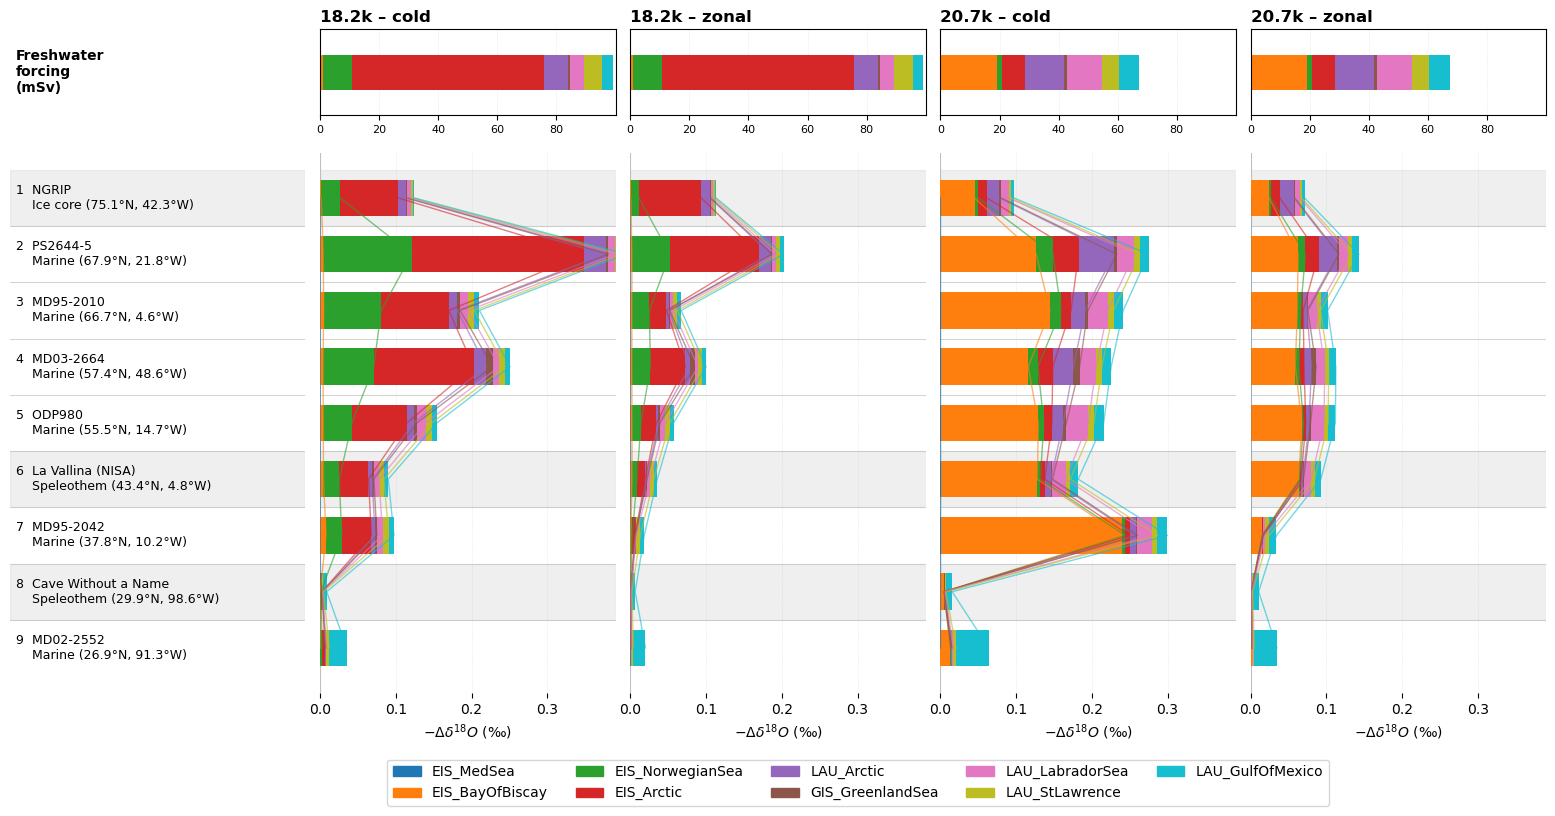

In [52]:
scen_mode = [

    ("18.2k", "cold"),
    ("18.2k", "zonal"),
    ("20.7k", "cold"),
    ("20.7k", "zonal"),

]

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================================
# Dye names
# ==========================================================

dye_labels = {
    row["dye"]: row["region"]
    for _,row in DYE_TABLE.iterrows()
}

dye_colors = {'dye00':'tab:blue', 'dye01':'tab:orange', 'dye02':'tab:green', 'dye03':'tab:red', 'dye04':'tab:purple', 'dye05':'tab:brown', 'dye06':'tab:pink',
         'dye07':'tab:olive', 'dye08':'tab:cyan'}

scale_Sv_to_mSv = 1000
xmax_discharge = 100

region_names = list(lookup_dis["17.8k"].keys())

xmax = 0.39



# ==========================================================
# Sort sites north -> south from PROXYSITES
# ==========================================================

sites = sorted(
    PROXYSITES.items(),
    key=lambda x: x[1]["lat"],
    reverse=True,
)

site_order = [s[0] for s in sites]

site_numbers = {
    site: i + 1
    for i, site in enumerate(site_order)
}


# ==========================================================
# Identify land sites
# ==========================================================

land_indices = [
    i for i, site in enumerate(site_order)
    if PROXYSITES[site]["domain"] == "land"
]


# ==========================================================
# Figure layout (discharge row + proxy contribution row)
# ==========================================================

fig = plt.figure(figsize=(16, 8))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=5,
    height_ratios=[0.16, 1],
    width_ratios=[1, 1, 1, 1, 1],
    hspace=0.12,
    wspace=0.05
)


# empty label space above site names
ax_dis_label = fig.add_subplot(gs[0,0])
ax_dis_label.axis("off")


# discharge axes
bar_axes = [
    fig.add_subplot(gs[0,i])
    for i in range(1,5)
]


# site labels
ax_label = fig.add_subplot(gs[1,0])


# proxy contribution axes
axes = [
    fig.add_subplot(
        gs[1,i],
        sharey=ax_label
    )
    for i in range(1,5)
]


# ==========================================================
# Common y-axis (north -> south)
# ==========================================================

for ax in [ax_label] + axes:
    ax.set_ylim(
        len(site_order)-0.2,
        -0.8
    )


# ==========================================================
# Label panel
# ==========================================================

ax_label.set_xlim(0, 1)
ax_label.axis("off")


# grey background behind labels
for i in land_indices:

    ax_label.axhspan(
        i - 0.5,
        i + 0.5,
        color="lightgrey",
        alpha=0.35,
        zorder=0
    )


# row separators behind labels
for y in range(1, len(site_order)):

    ax_label.axhline(
        y - 0.5,
        color="0.75",
        linewidth=0.5,
        zorder=1
    )


# vertical separator between labels and plots
ax_label.spines["right"].set_visible(True)
ax_label.spines["right"].set_color("0.75")
ax_label.spines["right"].set_linewidth(0.8)


# labels
for i, site in enumerate(site_order):

    info = PROXYSITES[site]

    lat = info["lat"]
    lon = info["lon"]

    lat_text = f"{abs(lat):.1f}°{'N' if lat >= 0 else 'S'}"
    lon_text = f"{abs(lon):.1f}°{'E' if lon >= 0 else 'W'}"

    type_short = {
        "Marine Sediment Core": "Marine",
        "Speleothem": "Speleothem",
        "Ice Core": "Ice core",
    }

    label = (
        f"{site_numbers[site]}  {site}\n"
        f"    {type_short.get(info['type'], info['type'])} "
        f"({lat_text}, {lon_text})"
    )

    ax_label.text(
        0.02,
        i,
        label,
        ha="left",
        va="center",
        fontsize=9
    )



# ==========================================================
# Freshwater discharge bars
# ==========================================================

for ax, (scenario, mode) in zip(bar_axes, scen_mode):

    left = 0

    for dye in dyes:

        #region = dye_labels[dye]

        value = (
            lookup_dis[scenario]
            .get(dye, 0.0)
            * scale_Sv_to_mSv
        )


        ax.barh(
            0,
            value,
            left=left,
            height=0.65,
            color=dye_colors[dye],
            edgecolor="none",
        )

        left += value


    ax.set_xlim(
        0,
        xmax_discharge
    )

    ax.set_ylim(
        -0.8,
        0.8
    )


    ax.set_title(
        f"{scenario} – {mode}",
        fontsize=12,
        weight="bold",
        loc="left",
        pad=5
    )


    ax.set_yticks([])


    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.5,
        alpha=0.4
    )


    ax.set_axisbelow(True)


    for spine in ax.spines.values():
        spine.set_visible(True)

    ax.set_xticks([0, 20, 40,60,80])
    ax.set_xticklabels(
        ["0", "20", "40","60", "80"],
        fontsize=8
    )


    #ax.tick_params(
    #    bottom=False,
    #    labelbottom=False,
    #    left=False
    #)


# label for discharge row
ax_dis_label.text(
    0.02,
    0.5,
    "Freshwater\nforcing\n(mSv)",
    fontsize=10,
    weight="bold",
    ha="left",
    va="center",
)


# ==========================================================
# Bar plots
# ==========================================================

for ax, (scenario, mode) in zip(axes, scen_mode):


    # grey background for land sites
    for i in land_indices:

        ax.axhspan(
            i - 0.5,
            i + 0.5,
            color="lightgrey",
            alpha=0.35,
            zorder=0
        )


    # store cumulative dye boundaries
    boundaries = {
        dye: []
        for dye in dyes
    }


    for i, site in enumerate(site_order):
    
        left = 0
    
        for dye in dyes:
    
            value = abs(
                proxymag[scenario][mode][site][dye]
            )
    
            # store right edge of this dye
            boundaries[dye].append(left + value)
    
            ax.barh(
                i,
                value,
                left=left,
                height=0.65,
                color=dye_colors[dye],
                edgecolor="none",
                zorder=3
            )
    
            left += value
    
    
    # connect dye contributions between sites
    for dye in dyes:
    
        ax.plot(
            boundaries[dye],
            range(len(site_order)),
            color=dye_colors[dye],
            linewidth=1,
            alpha=0.6,
            zorder=4
        )


    # limits
    ax.set_xlim(
        0,
        xmax
    )


    # remove panel boxes
    for spine in ax.spines.values():
        spine.set_visible(False)


    # row separators
    for y in range(1, len(site_order)):

        ax.axhline(
            y - 0.5,
            color="0.75",
            linewidth=0.5,
            zorder=2
        )


    # column separators
    ax.axvline(
        0,
        color="0.75",
        linewidth=0.8,
        zorder=2
    )


    # grid
    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.5,
        alpha=0.4,
        zorder=1
    )

    ax.set_axisbelow(True)


    # left aligned titles
    #ax.set_title(
    #    f"{scenario} – {mode}",
    #    fontsize=12,
    #    weight="bold",
    #    loc="left",
    #    pad=12
    #)


    ax.set_xlabel(
        r"$-\Delta\delta^{18}O$ (‰)",
        fontsize=10
    )


    ax.tick_params(
        axis="y",
        left=False,
        labelleft=False
    )


# ==========================================================
# Legend
# ==========================================================

handles=[
    mpl.patches.Patch(
        color=dye_colors[dye],
        label=dye_labels[dye]
    )
    for dye in dyes
]

fig.legend(
    handles=handles,
    #labels=dye_labels,
    loc="lower center",
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.55, -0.03)
)


# ==========================================================
# Title and spacing
# ==========================================================

#fig.suptitle(
#    "Contribution of meltwater source regions to proxy-site δ$^{18}$O anomalies",
#    fontsize=14,
#    weight="bold",
#    x=0.5
#)








plt.subplots_adjust(
    left=0.02,
    right=0.98,
    bottom=0.12,
    top=0.95
)

plt.savefig("my_output/chapter-four_latestfigures/SFig7_b_ProxySites_Bars_var.pdf", dpi=300, bbox_inches="tight")



plt.show()